In [1]:
#!uv pip install shap
#!uv pip install catboost

In [2]:
import os
import glob
import numpy as np
import altair as alt
import polars as pl
import pandas as pd
import shap
from catboost import CatBoostRegressor, Pool


from birds.source_data.nabbp import LookupTables, DataTables
from birds.source_data.iucn import IUCNDataTables
from birds.settings import load_settings, get_relative_path


from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.metrics import make_scorer, mean_squared_error, r2_score

/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

In [ ]:
## TODO:
# 0. DONE - update agg to include year month day for banding date 
# 1. DONE - Update cleaning to set first_to_last_km=0 where banding or last lat/lon = 0 - metri not used, skip
# 2. DONE - Add explicit data type for banding year month day - appears to work fine w/o, skip
# 3. DONE - Define composite days * num_events as feature
# 3. DONE - Regenerate data

# 4. DONE - Add sklearn scoring mechanisms mse, rmse, mae, r2
# 4. DONE - determine best models from sv run
# 4. DONE - remove outliers from training set to see if best perf improves. - regularization should address this, skip
# 4. DONE - add dummy regressor for comparison on scoring mechanisms to best model
# 5. WONTDO - try pycaret for model comparison?

# 6. DONE - Get working in Google collab and use GPU

# 7. DONE - Evaluate model using SHAP

# 8.  WONTDO - build new model against event_num_days_span (separate notebook) and evaluate with same methods.   

# 9. Create residual plots for best model
# 9. DONE Add shap heatmap for most important features
# 10. DONEVisually Analyze the influence of species
# 11. DONE Visually Analyze the influence of year


# for species and year analysis use dependence plot
# The best way to understand the influence of a single feature using SHAP is by creating a dependence plot. This scatter plot shows the SHAP value for a specific feature on the y-axis against the feature's actual values on the x-axis, revealing how the feature's impact changes across different data points. To reveal interactions with other features, you can color-code the points by another feature's value.  


# perform ablation analysis
# perform senistivity analysis
# perform error analysis on 3 samples with high error

In [5]:
settings = load_settings()
lookup = LookupTables()

In [6]:
modelpath = get_relative_path(settings.model_path)

In [7]:
def load_agg_data_files(nfiles):
    data_dir = get_relative_path(get_relative_path(settings.augmented_band_agg))
    print(data_dir)

    all_files = sorted(glob.glob(os.path.join(data_dir, "nabbp_band_agg_*.parquet")))

    if nfiles > 0:
        all_files = all_files[-nfiles:]
    
    print(f"Loading {len(all_files)} files from {data_dir}")
    df = pl.concat([pl.read_parquet(f) for f in all_files])
    return df


df = load_agg_data_files(99)

../data/augmented_data/band_agg
Loading 57 files from ../data/augmented_data/band_agg


In [8]:
df.head()

banding_record_id,banding_band,banding_date,banding_day,banding_month,banding_year,banding_species_id,banding_iso_country,banding_iso_subdivision,banding_band_type_code,banding_bird_status,banding_age_code,banding_sex_code,banding_event_type,banding_band_status_code,banding_extra_info_code,banding_lat_dd,banding_lon_dd,banding_coordinates_precision_code,banding_permit,banding_record_source,num_events,last_event_date,last_how_obtained_code,last_who_obtained_code,last_reporting_method,last_present_condition,last_lat_dd,last_lon_dd,last_iso_country,last_iso_subdivision,event_days_span,first_to_last_km,num_event_days_span
i64,str,date,i64,i64,i64,i64,str,str,str,str,str,str,str,str,str,f64,f64,str,str,str,i64,date,i64,i64,i64,i64,f64,f64,str,str,i64,f64,i64
-42574156,"""B58235077397""",2005-07-29,29,7,2005,1691,"""CA""","""CA-ON""","""1""","""3""","""1""","""5""","""B""","""0""","""00""",55.5,-83.5,"""60.0""","""P8832232""","""B""",1,2005-10-13,1,21,6,3,52.41667,-109.25,"""CA""","""CA-SK""",76,1708.745971,76
-16205515,"""B17815174927""",2017-07-15,15,7,2017,1710,"""CA""","""CA-NU""","""41""","""3""","""1""","""5""","""B""","""0""","""00""",67.5,-101.5,"""60.0""","""P7837928""","""B""",1,2018-12-08,1,21,7,5,34.30495,-91.98342,"""US""","""US-AR""",511,3741.442839,511
19818780,"""B67765371626""",2023-07-19,19,7,2023,1690,"""CA""","""CA-NT""","""9999""","""3""","""5""","""5""","""B""","""0""","""00""",72.5,-124.5,"""60.0""","""P8830613""","""B""",1,2025-04-09,1,21,7,5,50.57183,-112.95173,"""CA""","""CA-AB""",630,2503.432432,630
-42853666,"""B88845010098""",1976-10-29,29,10,1976,1690,"""US""","""US-NE""","""11""","""3""","""1""","""5""","""B""","""0""","""19""",41.5,-96.5,"""60.0""","""P9953434""","""B""",1,1981-12-06,1,20,1,5,40.75,-95.58333,"""US""","""US-IA""",1864,113.357308,1864
-42949648,"""B48495419884""",2003-08-02,2,8,2003,1690,"""US""","""US-AK""","""1""","""3""","""4""","""4""","""B""","""0""","""00""",70.5,-154.5,"""60.0""","""P4741797""","""B""",1,2009-05-22,1,21,61,5,69.41667,-130.25,"""CA""","""CA-NT""",2120,925.553743,2120


In [9]:
cat_cols = [ 'banding_species_id','banding_iso_country', 'banding_iso_subdivision','banding_band_type_code','banding_bird_status',
               'banding_age_code', 'banding_sex_code', 'banding_event_type', 'banding_band_status_code', 'banding_extra_info_code',
               'banding_coordinates_precision_code', 'banding_permit', 'banding_day', 'banding_month', 'banding_year', 'banding_record_source',            
]

banding_columns = [
 'banding_day',
 'banding_month',
 'banding_year',
 'banding_species_id',
 'banding_iso_country',
 'banding_iso_subdivision',
 'banding_band_type_code',
 'banding_bird_status',
 'banding_age_code',
 'banding_sex_code',
 'banding_event_type',
 'banding_band_status_code',
 'banding_extra_info_code',
 'banding_lat_dd',
 'banding_lon_dd',
 'banding_coordinates_precision_code',
 'banding_permit',
 'banding_record_source',
 'event_days_span'
]

#filter df to only banding columns
df_banding = df.select(banding_columns)

In [10]:
df_banding_pd = df_banding.to_pandas()

In [11]:
# remove species ids with less than 10 records.   Needed for reasonable train/test split
species_counts = df_banding_pd['banding_species_id'].value_counts().to_frame().reset_index()
limited_species= species_counts[species_counts['count'] < 10]['banding_species_id'].to_list()
limited_species

df_banding_pd = df_banding_pd[~df_banding_pd['banding_species_id'].isin(limited_species)]

In [12]:
# Split while maintaining species proportions
X = df_banding_pd.drop(columns=['event_days_span'])  # Remove target from features
y = df_banding_pd['event_days_span']


X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,
    stratify=X['banding_species_id'],  # files are split by species_id and were loaded in order ensure distribution across train/test
    random_state=1
)

# Verify proportions
#print("Training set species distribution:")
#print(X_train['banding_species_id'].value_counts(normalize=True).sort_index())
#print("\nTest set species distribution:")
#print(X_test['banding_species_id'].value_counts(normalize=True).sort_index())

In [13]:
# Use subset for hyperparameter tuning
sample_size = min(3000000, len(X_train)) 
sample_indices = np.random.choice(len(X_train), sample_size, replace=False)

X_train_sample = X_train.iloc[sample_indices]
y_train_sample = y_train.iloc[sample_indices]

model_save_path = os.path.join(modelpath, 'catboost_bestparms-FullTrain-500iter-20251005.cbm')
#model_save_path = '../models/event_span/catboost_bestparms-FullTrain-500iter-20251005.cbm'


# if file exists on model_save_path, load it, else build new:
if os.path.exists(model_save_path):
    print(f"Loading model from {model_save_path}")
    best_model = CatBoostRegressor()
    best_model.load_model(model_save_path)
    print("Model loaded.")
else:
    # Build new model
    model = CatBoostRegressor(
        random_seed=42,
        verbose=False,
        cat_features=cat_cols,
        boosting_type='Plain'
    )

    # param_grid = {
    #     'iterations': [500],
    #     'learning_rate': [0.01, 0.03, 0.05],
    #     'depth': [4, 6, 8],
    #     'l2_leaf_reg': [1, 3, 5]
    # }

    param_grid = {
        'iterations': [500],
        'learning_rate': [0.03],
        'depth': [8],
        'l2_leaf_reg': [3]
    }


    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=12,  
        verbose=2,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    # Results
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV RMSE: {-grid_search.best_score_:.3f}")

    # Get detailed results
    results_df = pd.DataFrame(grid_search.cv_results_)
    results_df = results_df.sort_values('rank_test_score')
    print(results_df[['params', 'mean_test_score', 'std_test_score']].head(10))

    # Use best model
    best_model = grid_search.best_estimator_

    best_model.save_model(model_save_path)
    print(f"Best model saved to: {model_save_path}")

Loading model from ../data/models/catboost_bestparms-FullTrain-500iter-20251005.cbm
Model loaded.


### Best Model Hyperparams and Scores in 5 fold CV with 25000 row sample

#### Param Grid
param_grid = {
 'iterations': [500, 1000, 1500],
 'learning_rate': [0.01, 0.03, 0.05],
 'depth': [4, 6, 8],
 'l2_leaf_reg': [1, 3, 5]
}



#### Results
Best parameters: {'depth': 8, 'iterations': 1500, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Best CV RMSE: 1094.483
                                               params  mean_test_score  \
76  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1094.482810   
80  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1094.682668   
67  {'depth': 8, 'iterations': 1000, 'l2_leaf_reg'...     -1094.724839   
62  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1094.892855   
38  {'depth': 6, 'iterations': 1000, 'l2_leaf_reg'...     -1094.908113   
71  {'depth': 8, 'iterations': 1000, 'l2_leaf_reg'...     -1094.910831   
29  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1095.418559   
47  {'depth': 6, 'iterations': 1500, 'l2_leaf_reg'...     -1095.473684   
64  {'depth': 8, 'iterations': 1000, 'l2_leaf_reg'...     -1095.534402   
73  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1095.555317   

    std_test_score  
76       39.914299  
80       40.521431  
67       39.411480  
62       39.159821  
38       40.759246  
71       39.665232  
29       39.553189  
47       39.997007  
64       39.271205  
73       39.527004  
Best model saved to: ../models/event_span/catboost_gridsearch_best_test20251005-hp-2.cbm


>>##### Results with best parms 25k train sample
>>Best CV RMSE: 1142.568
>>                                            params  mean_test_score  \
>>0  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1142.567934   
>>
>>std_test_score  
>>0       52.371538 

>>##### Results with best parms 50k train sample
>>time: 02:50
>>Best parameters: {'depth': 8, 'iterations': 1500, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
>>Best CV RMSE: 1105.313
>>                                              params  mean_test_score  \
>>0  {'depth': 8, 'iterations': 1500, 'l2_leaf_reg'...     -1105.313214   
>>
>>   std_test_score  
>>0       30.596612 

>>##### Ressults with best parms 100k train sample
>>time: DNF




#### Results with only iter 500

param_grid = {
    'iterations': [500],
    'learning_rate': [0.01, 0.03, 0.05],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}

Best parameters: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 1, 'learning_rate': 0.03}
Best CV RMSE: 1133.390
                                               params  mean_test_score  \
19  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1133.389678   
25  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1133.798901   
23  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1134.310499   
22  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1134.695356   
26  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1134.951518   
14  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1134.987808   
11  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1135.269154   
20  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1135.505430   
17  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1136.142223   
13  {'depth': 6, 'iterations': 500, 'l2_leaf_reg':...     -1136.368635   

    std_test_score  
19       58.283129  
25       58.237627  
23       58.133233  
22       57.802567  
26       58.206145  
14       58.417549  
11       58.436724  
20       58.179477  
17       58.443508  
13       58.078234  
Best model saved to: ../models/event_span/catboost_gridsearch-best500ier-20251005.cbm




#### Additional manual testing


---------------------------------------------------
sample FULL train

time: 00:25:42
Best parameters: {'depth': 8, 'iterations': 500, 'l2_leaf_reg': 3, 'learning_rate': 0.03}
Best CV RMSE: 1078.585
                                              params  mean_test_score  \
0  {'depth': 8, 'iterations': 500, 'l2_leaf_reg':...     -1078.585395   

   std_test_score  
0        2.738958  
Best model saved to: ../models/event_span/catboost_bestparms-FullTrain-500iter-20251005.cbm
MSE: 1169223.7283194065
R2: 0.2776840805789518
RMSE: 1081.3064913887304

In [14]:
# comparison to dummy regressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create a mean baseline
#baseline = DummyRegressor(strategy="quantile", quantile=0.99) #DummyRegressor(strategy='mean')
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

# Evaluate
print(f"Baseline MSE: {mean_squared_error(y_test, y_pred)}")
print(f"Baseline R2: {r2_score(y_test, y_pred)}")
print(f"Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

Baseline MSE: 1618716.0593925703
Baseline R2: -5.562685210236396e-07
Baseline RMSE: 1272.2877266532796


In [15]:
# Test best model on test set

predictions = best_model.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, predictions)}")
print(f"R2: {r2_score(y_test, predictions)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions))}")


MSE: 1169223.7283194065
R2: 0.2776840805789518
RMSE: 1081.3064913887304


In [16]:
explainer = shap.TreeExplainer(best_model)  # model is CatBoostRegressor
shap_values = explainer.shap_values(X_test)

In [17]:
best_model.get_feature_importance(prettified=True)

,Feature Id,Importances
0,banding_species_id,19.135083
1,banding_year,13.952507
2,banding_age_code,13.245814
3,banding_lat_dd,11.384093
4,banding_band_type_code,9.363533
5,banding_lon_dd,6.588541
6,banding_permit,5.267527
7,banding_iso_subdivision,4.540994
8,banding_sex_code,4.342898
9,banding_coordinates_precision_code,3.826938


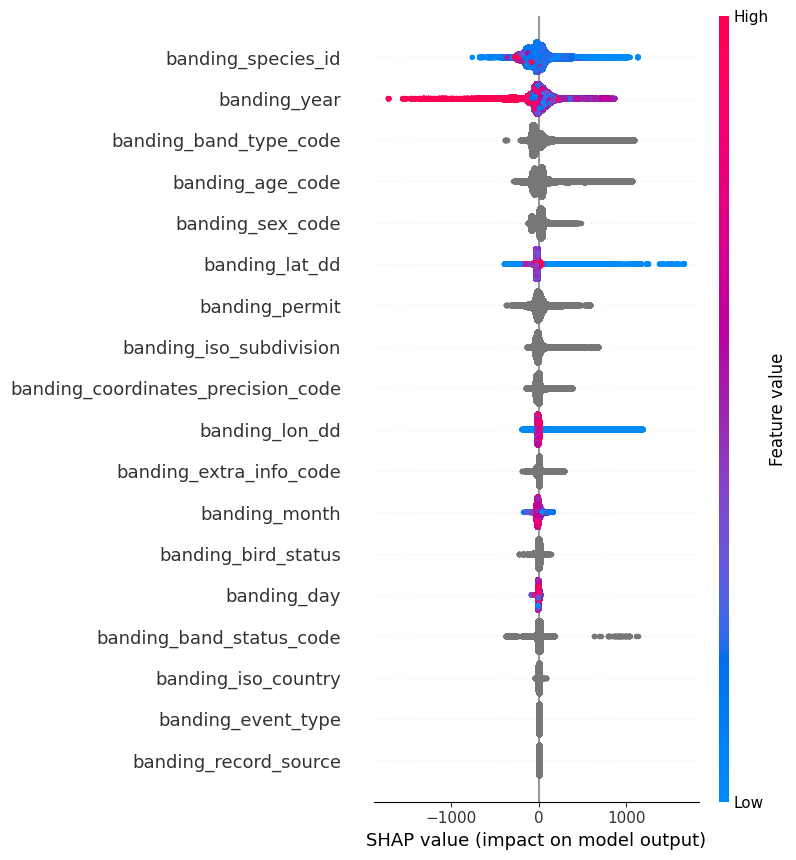

In [18]:
shap.summary_plot(shap_values, X_test)

In [19]:
shap.force_plot(explainer.expected_value, shap_values[0], X_test.iloc[0])

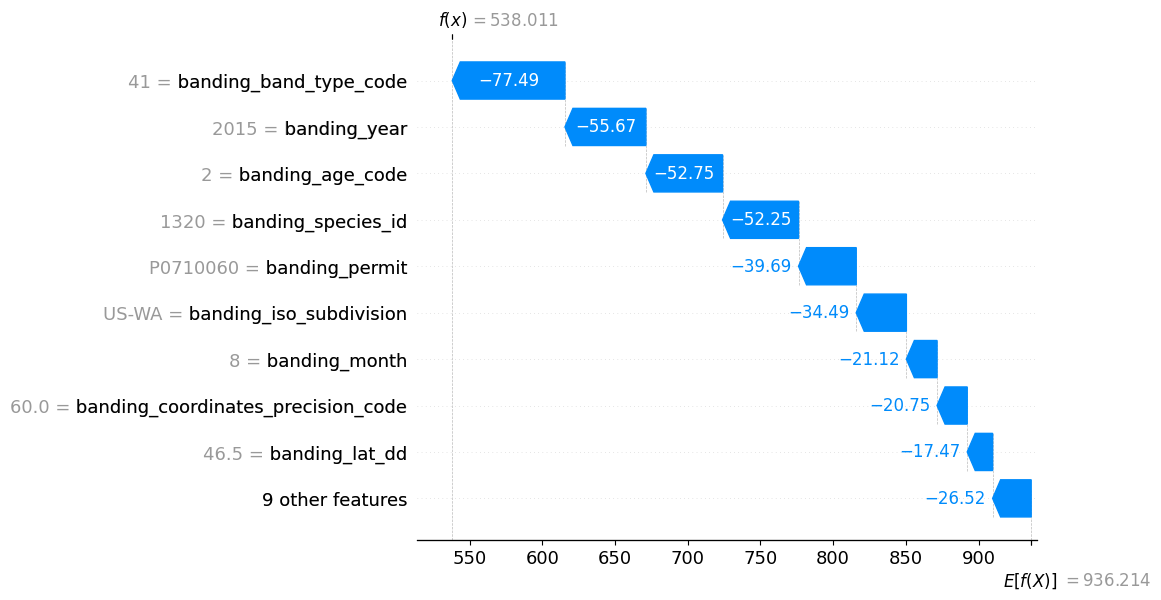

In [20]:
shap.plots.waterfall(explainer(X_test)[10])

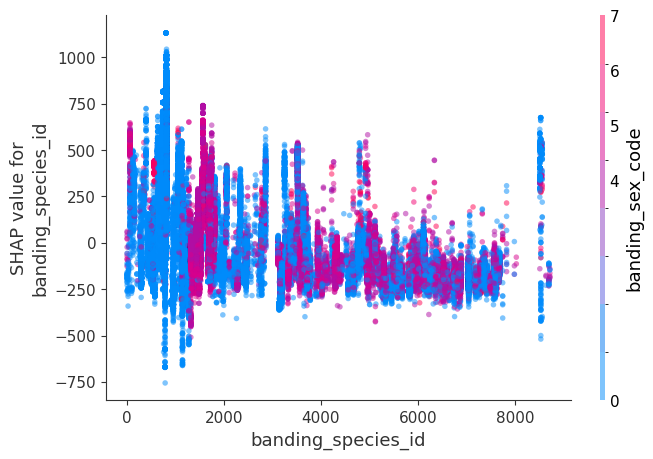

In [21]:
shap.dependence_plot("banding_species_id", shap_values, X_test, interaction_index='auto', alpha=0.5)

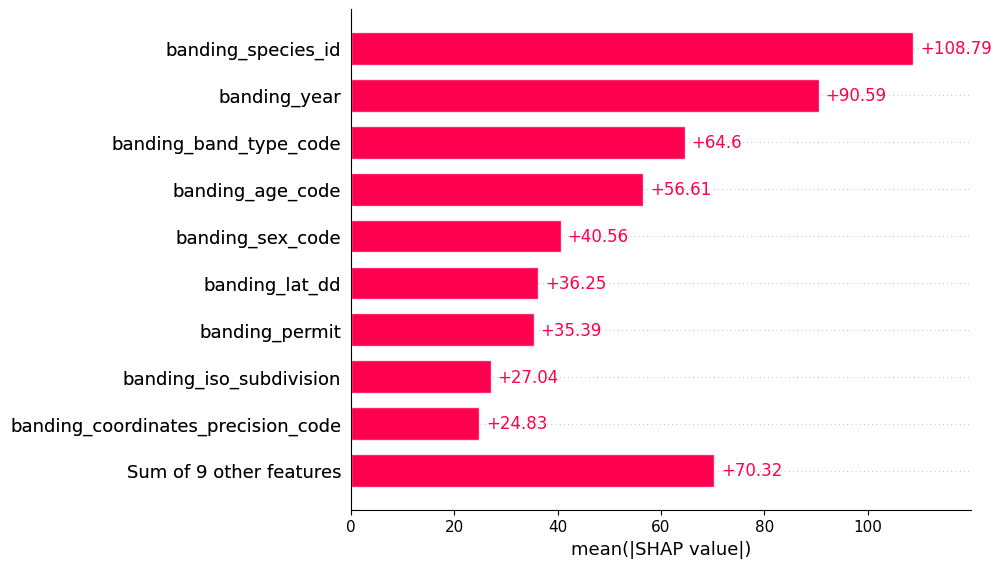

In [22]:
shap.plots.bar(explainer(X_test))

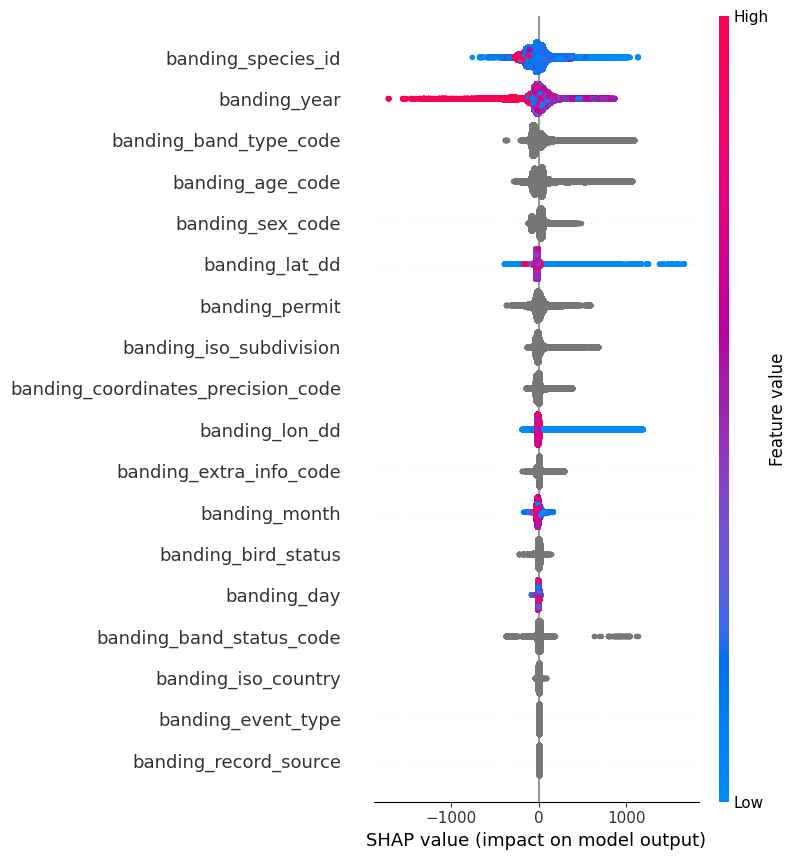

In [23]:
shap.summary_plot(shap_values, X_test)

In [24]:
# Find which species are the influential ones
shap_contrib = shap_values[:, :-1]
species_idx = list(X_test.columns).index('banding_species_id')

# Create a dataframe to analyze
species_impact = pd.DataFrame({
    'species_id': X_test['banding_species_id'],
    'shap_value': shap_contrib[:, species_idx]
})

# Find the high-impact species
high_impact_species = species_impact.groupby('species_id').agg({
    'shap_value': ['mean', 'count', 'std']
}).sort_values(('shap_value', 'mean'), ascending=False)

print("Top 10 most positive species:")
print(high_impact_species.head(10))

print("\nTop 10 most negative species:")
print(high_impact_species.tail(10))

# Check the distribution
print(f"\nTotal unique species: {X_test['banding_species_id'].nunique()}")
print(f"Species with mean SHAP > 500: {(high_impact_species[('shap_value', 'mean')] > 500).sum()}")

Top 10 most positive species:
            shap_value                   
                  mean  count         std
species_id                               
811         635.435903    130   82.548143
1570        607.766551    283   93.701682
8522        549.233560     41   70.379179
400         494.703172    111  146.983804
821         491.039443  19375  204.041824
620         469.147458      6   22.880647
640         453.290215    710   86.357694
720         440.809037   1423  105.011354
8554        429.810710     36  108.689111
1620        422.960460     40  101.432549

Top 10 most negative species:
            shap_value                 
                  mean count        std
species_id                             
5450       -272.487626    15  40.420177
1180       -276.053499     2  12.561845
6031       -289.461688     3  30.866959
922        -319.103547    65  17.735991
3170       -321.157603    16  26.888252
1850       -322.256935     3   1.222228
3140       -335.504037   103  16.

In [25]:
species = lookup.species[['SPECIES_ID','SPECIES_NAME','SCI_NAME']]

# Merge with the high impact species
# convert high_impact_species index to column
high_impact_species_col = high_impact_species.reset_index()

# high_impact_species_col = high_impact_species_col.merge(
#     species,
#     left_on='species_id',
#     right_on='SPECIES_ID',
#     how='left'
# )

high_impact_species_col
# high_impact_species_col = high_impact_species_col.drop(columns=['SPECIES_ID'])

# high_impact_species_col

species_id  shap_value                   
                      mean  count         std
0          811  635.435903    130   82.548143
1         1570  607.766551    283   93.701682
2         8522  549.233560     41   70.379179
3          400  494.703172    111  146.983804
4          821  491.039443  19375  204.041824
..         ...         ...    ...         ...
634       1850 -322.256935      3    1.222228
635       3140 -335.504037    103   16.702395
636       1321 -381.240580     27   43.353355
637       1282 -387.263757     82   21.585977
638       8553 -401.594909      2    6.696440

[639 rows x 4 columns]

In [26]:
#save model to ../models/event_span/event_span_base_nosplit.cbm
#model_path = get_relative_path(settings.event_span_model)
#model.save_model('../models/event_span/event_span_base_nosplit.cbm') #10min to train on full data

In [27]:
# pl.Config.set_tbl_rows(50)
# null_stats = pl.DataFrame({
#     "column": df.columns,
#     "null_count": [df.select(pl.col(col).null_count()).item() for col in df.columns],
#     "null_rate": [(df.select(pl.col(col).null_count()).item() / df.height) * 100 for col in df.columns]
# }).sort("null_rate", descending=True)

# null_stats.head(100)

In [28]:
#df_banding_pd[df_banding_pd['event_days_span']==4]

In [29]:
# altair histogram of event_days_span
chart = alt.Chart(df_banding_pd).mark_bar().encode(
    alt.X("event_days_span", bin=alt.Bin(maxbins=1000)),
    y='count()',
).properties(
    title="Distribution of Event Days Span",
    width=800,
    height=400
)

chart

alt.Chart(...)

In [30]:
# altair histogram of banding_year
chart = alt.Chart(df_banding_pd).mark_bar().encode(
    alt.X("banding_year", bin=alt.Bin(maxbins=100)),
    y='count()',
).properties(
    title="Distribution of Banding Year",
    width=800,
    height=400
)   

chart

alt.Chart(...)

In [31]:
#df_banding_pd['banding_year'].quantile([.95])

In [32]:
# Get feature importances (after training your model)
feature_importance = best_model.get_feature_importance()
feature_names = best_model.feature_names_

# Create a dataframe for easier viewing
import pandas as pd
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)

                               feature  importance
3                   banding_species_id   19.135083
2                         banding_year   13.952507
8                     banding_age_code   13.245814
13                      banding_lat_dd   11.384093
6               banding_band_type_code    9.363533
14                      banding_lon_dd    6.588541
16                      banding_permit    5.267527
5              banding_iso_subdivision    4.540994
9                     banding_sex_code    4.342898
15  banding_coordinates_precision_code    3.826938
12             banding_extra_info_code    3.780988
11            banding_band_status_code    1.539425
1                        banding_month    1.269904
7                  banding_bird_status    1.042197
4                  banding_iso_country    0.542548
0                          banding_day    0.177010
10                  banding_event_type    0.000000
17               banding_record_source    0.000000
